=== INFORME DE INTELIGENCIA DE NEGOCIOS: INMOBILIARIA ECUADOR ===
Total de propiedades analizadas: 200000


Precio Promedio General: $732.35


Costo Promedio por m2: $5.89



--- PRECIO PROMEDIO POR CIUDAD (TOP 10) ---
Ciudad
Cotopaxi                         3697.685799
Eugenio Espejo                   3482.206837
Samborondón                      2289.860858
Avenida Francisco de Orellana    1714.420480
Avenida Los Arrozales            1197.930281
Quito 170132                     1128.263136
La Pradera                        894.766588
Guayaquil 090513                  813.988978
Cumbayá                           813.104147
Quito                             767.403245
Name: Precio, dtype: float64

--- RANGO DE PRECIOS POR PROVINCIA ---
                 min       max         mean
Provincia                                  
Cotopaxi       94.47   4557.66  1814.528859
El Oro         98.42    155.03   124.352068
Esmeraldas    111.33    620.53   327.772537
Guayas        130.85   2816.34   61

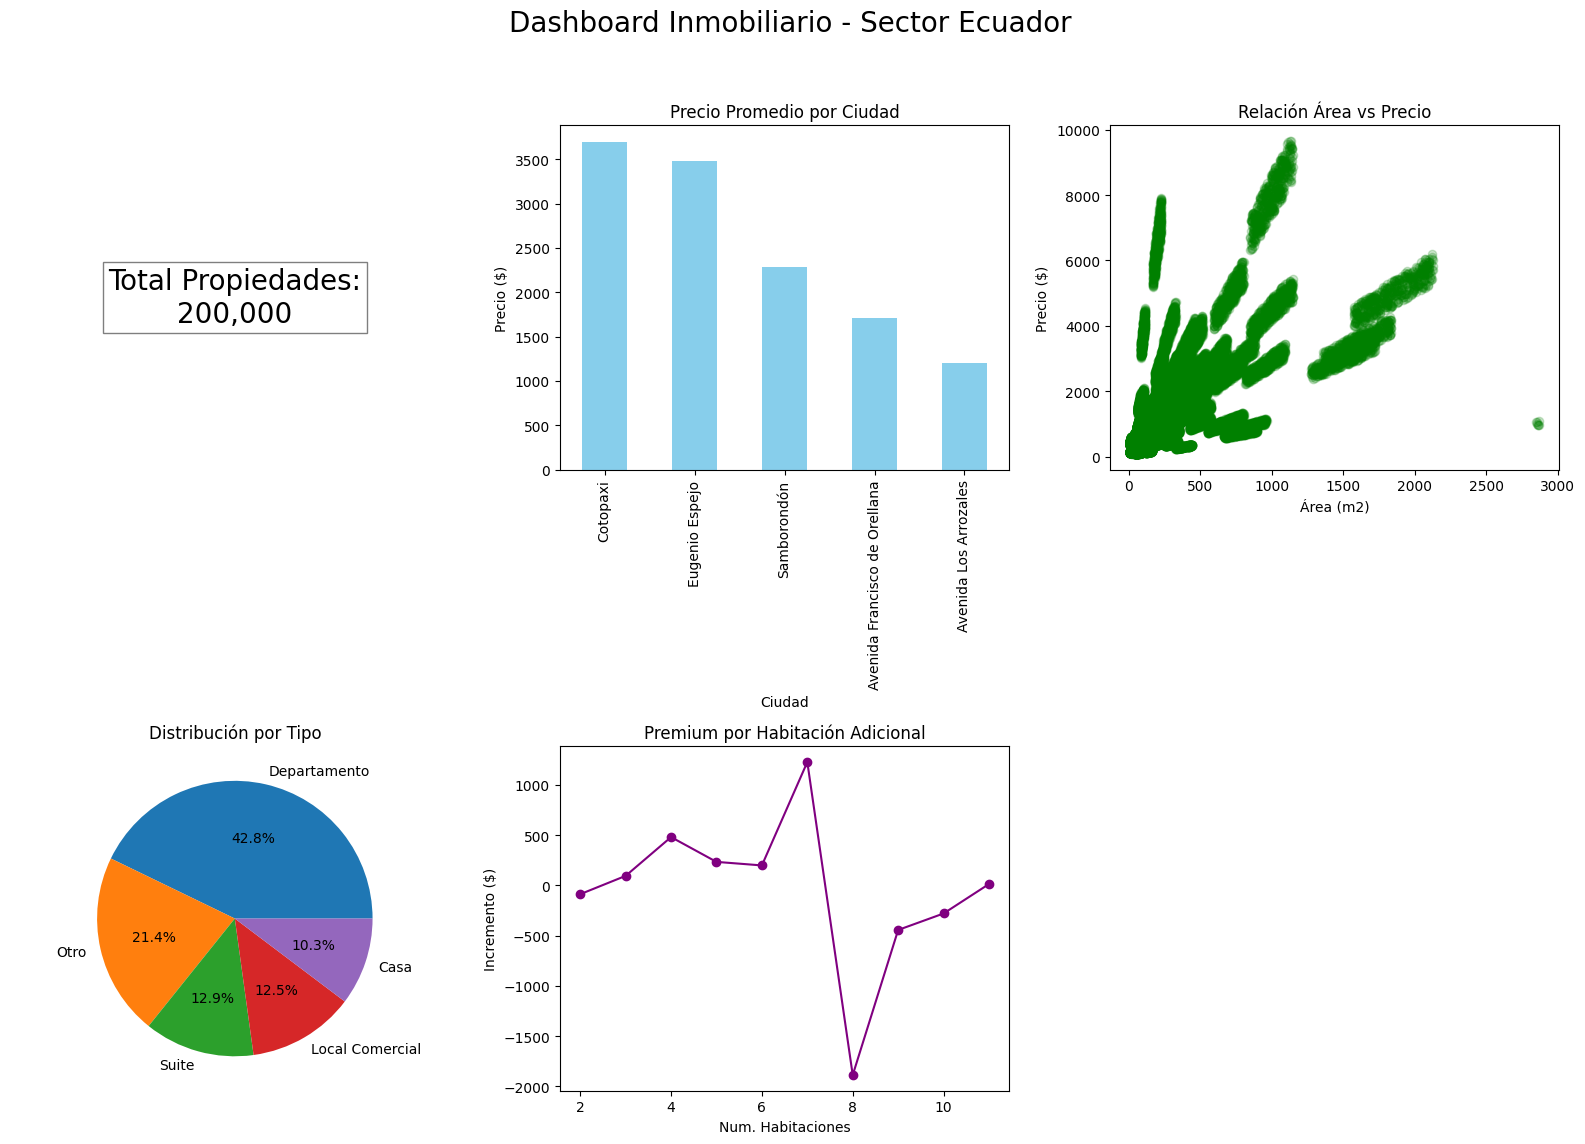

In [21]:
import pandas as pd

# 1. Carga y preparación de datos
df = pd.read_csv('real_estate_ecuador_200k.csv')
df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
df['Ciudad'] = df['Lugar'].str.split(',').str[2].str.strip()

# 2. Cálculos para Perspectiva Financiera
promedio_general = df['Precio'].mean()
promedio_ciudad = df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(10)
df['Costo_m2'] = df['Precio'] / df['Area']
costo_m2_promedio = df['Costo_m2'].mean()
rango_provincia = df.groupby('Provincia')['Precio'].agg(['min', 'max', 'mean'])

# 3. Cálculos para Perspectiva de Producto
def extract_tipo(titulo):
    titulo = str(titulo).lower()
    if 'suite' in titulo: return 'Suite'
    if 'casa' in titulo: return 'Casa'
    if 'departamento' in titulo or 'depto' in titulo: return 'Departamento'
    if 'local' in titulo or 'comercial' in titulo: return 'Local Comercial'
    return 'Otro'

df['Tipo_Propiedad'] = df['Titulo'].apply(extract_tipo)
distribucion_tipo = df['Tipo_Propiedad'].value_counts()
tamano_provincia = df.groupby('Provincia')['Area'].mean()
premium_habitacion = df.groupby('Num. dormitorios')['Precio'].mean().diff()

# 4. Cálculos para Perspectiva Geográfica
top_5_caras = df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(5)
concentracion_oferta = df['Ciudad'].value_counts().head(10)

# 5. Segmentación de Mercado
Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)
df['Tipo_Inmueble'] = pd.cut(df['Precio'], bins=[-float('inf'), Q1, Q3, float('inf')],
                             labels=['Económico', 'Medio', 'Lujo'])
segmentacion = df['Tipo_Inmueble'].value_counts()

# --- IMPRESIÓN DEL INFORME ---
print("=== INFORME DE INTELIGENCIA DE NEGOCIOS: INMOBILIARIA ECUADOR ===")
print(f"Total de propiedades analizadas: {len(df)}")
print("\n")
print(f"Precio Promedio General: ${promedio_general:.2f}")
print("\n")
print(f"Costo Promedio por m2: ${costo_m2_promedio:.2f}")
print("\n")

print("\n--- PRECIO PROMEDIO POR CIUDAD (TOP 10) ---")
print(promedio_ciudad)

print("\n--- RANGO DE PRECIOS POR PROVINCIA ---")
print(rango_provincia)

print("\n--- DISTRIBUCIÓN POR TIPO DE PROPIEDAD ---")
print(distribucion_tipo)

print("\n--- TAMAÑO PROMEDIO POR PROVINCIA (m2) ---")
print(tamano_provincia)

print("\n--- PREMIUM (INCREMENTO) POR HABITACIÓN ADICIONAL ---")
print(premium_habitacion)

print("\n--- TOP 5 CIUDADES MÁS CARAS ---")
print(top_5_caras)

print("\n--- TOP 10 CIUDADES CON MAYOR OFERTA ---")
print(concentracion_oferta)

print("\n--- SEGMENTACIÓN DE MERCADO ---")
print(segmentacion)
print("================================================================")

import matplotlib.pyplot as plt

# Crear figura consolidada para el dashboard
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Inmobiliario - Sector Ecuador', fontsize=20)

# i. Total de propiedades
ax1 = fig.add_subplot(2, 3, 1)
ax1.text(0.5, 0.5, f'Total Propiedades:\n{len(df):,}',
         ha='center', va='center', fontsize=20, bbox=dict(facecolor='white', alpha=0.5))
ax1.axis('off')

# ii. Gráfico de barras: Precio promedio por Ciudad (Top 5)
ax2 = fig.add_subplot(2, 3, 2)
df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='skyblue', ax=ax2)
ax2.set_title('Precio Promedio por Ciudad')
ax2.set_ylabel('Precio ($)')

# iii. Gráfico de dispersión: Relación Área vs Precio
ax3 = fig.add_subplot(2, 3, 3)
# Filtro de outliers para mejorar la visualización
df_f = df[df['Area'] < df['Area'].quantile(0.99)]
ax3.scatter(df_f['Area'], df_f['Precio'], alpha=0.2, color='green')
ax3.set_title('Relación Área vs Precio')
ax3.set_xlabel('Área (m2)')
ax3.set_ylabel('Precio ($)')

# iv. Gráfico de pastel: Distribución por Tipo
ax4 = fig.add_subplot(2, 3, 4)
df['Tipo_Propiedad'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax4)
ax4.set_title('Distribución por Tipo')
ax4.set_ylabel('')

# v. Gráfico de Premium por Habitación Adicional
ax5 = fig.add_subplot(2, 3, 5)
df.groupby('Num. dormitorios')['Precio'].mean().diff().plot(kind='line', marker='o', ax=ax5, color='purple')
ax5.set_title('Premium por Habitación Adicional')
ax5.set_xlabel('Num. Habitaciones')
ax5.set_ylabel('Incremento ($)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



